# Описание файла

**Exploratory Data Analysis (EDA)**

В этом файле проводится разведочный анализ данных (Exploratory Data Analysis, EDA) датасета, содержащего информацию о клиентах банка и их реакции на маркетинговую кампанию по привлечению депозитов. Цель анализа — изучить структуру данных, выявить закономерности, аномалии и взаимосвязи между переменными, чтобы в дальнейшем построить прогнозную модель и оптимизировать маркетинговую стратегию.

**Описание признаков**

Датасет имеет следующие признаки/столбцы:
| Столбец   | Перевод                   | Описание                                                                                 |
| --------- | ------------------------- | ---------------------------------------------------------------------------------------- |
| age       | Возраст                   | Возраст клиента в годах                                                                  |
| job       | Работа                    | Тип занятости клиента (например, администратор, инженер, пенсионер и т.д.)               |
| marital   | Семейное положение        | Семейный статус клиента (замужем/женат, холост, в разводе и т.д.)                        |
| education | Образование               | Уровень образования клиента (среднее, высшее и т.д.)                                     |
| default   | Кредитный дефолт          | Есть ли у клиента невыполненные кредитные обязательства (да/нет)                         |
| balance   | Баланс                    | Среднегодовой баланс клиента в евро                                                      |
| housing   | Жилищный кредит           | Есть ли у клиента ипотечный кредит (да/нет)                                              |
| loan      | Личный кредит             | Есть ли у клиента персональный кредит (да/нет)                                           |
| contact   | Тип связи                 | Тип последней коммуникации с клиентом (телефон, email и т.д.)                            |
| day       | День                      | День месяца последнего контакта                                                          |
| month     | Месяц                     | Месяц последнего контакта                                                                |
| duration  | Длительность              | Длительность последнего контакта в секундах                                              |
| campaign  | Кампания                  | Количество контактов, проведённых для этого клиента во время текущей кампании            |
| pdays     | Дней с прошлого контакта  | Количество дней, прошедших с момента последнего контакта в предыдущей кампании           |
| previous  | Предыдущие контакты       | Количество контактов, проведённых для этого клиента до текущей кампании                  |
| poutcome  | Исход предыдущей кампании | Результат предыдущей маркетинговой кампании (успех, неудача, отсутствие контакта и т.д.) |
| deposit   | Депозит                   | Целевая переменная: оформил ли клиент депозит после текущей кампании (да/нет)            |

Этот набор признаков позволяет проанализировать демографические, финансовые и поведенческие характеристики клиентов, а также оценить эффективность маркетинговых коммуникаций.

# Импорт основных библиотек

In [1]:
# импорт модулей/библиотек для обработки данных
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
from my_def import *
import random

In [2]:
# импорт необходимого окружения для визуализации
# отключим предупреждения Anaconda
import warnings
warnings.simplefilter('ignore')

# будем отображать графики прямо в jupyter'e
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
#графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 

#увеличим дефолтный размер графиков
from pylab import rcParams
rcParams['figure.figsize'] = 8, 5
import pandas as pd

# 1. Изучение структуры данных

In [3]:
# выгрузка данных и последущий сбор информации о структуре данных
df = pd.read_csv('bank.csv')

# вывод основных характеристик данных (тип признаков, пропуски, структура ...)
df.info()

# явный вывод количеств строк и столбцов
count_rows, count_column = df.shape

print(f'Исходный датафрейм содержит {count_rows} строк и {count_column} столбцов')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
Исходный датафрейм содержит 11162 строк и 17 столбцов


In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
# для удобства EDA, введем список количественных и качественных признаков (используем списковое включение)

numerical_features = [x for x in df.columns if pd.api.types.is_numeric_dtype(df[x])]

categorical_features = [x for x in df.columns if not pd.api.types.is_numeric_dtype(df[x])]

In [6]:
print(f'{len(df[numerical_features].columns)} количественных признаков:{list(df[numerical_features])}')
print(f'{len(df[categorical_features].columns)} качественных признаков:{list(df[categorical_features])}')

7 количественных признаков:['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
10 качественных признаков:['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [7]:
# вывод статистики количесвенных призанков
print(df[numerical_features].describe())

                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.750000      1.000000  


* *balance*: огромный разброс (от −6847 до 81 204) и большая дисперсия — почти наверняка есть сильные выбросы. Отрицательный баланс тоже интересен: это долг/овердрафт или ошибка;
* *duration*: максимум 3881 — это почти 65 минут. Для звонка это очень много: либо редкие аномальные случаи, либо нужно проверить единицы измерения;
* *pdays*: значение −1 почти у половины наблюдений (50% = −1). Скорее всего, это кодировка «клиент не контактировали ранее». Это не выброс, а специальный маркер;
* *age*: распределение выглядит нормальным, но стоит проверить хвосты (95 лет — возможно, редкие кейсы);
* *campaign*: максимум 63 контакта с клиентом — это очень много. Стоит посмотреть, сколько таких строк и как они влияют на целевую переменную.


# 2. Проверка на корректность и качество данных

## 2.1 Проверка на дубликаты

In [8]:
# проверка наличия явных дубликатов в датасете
df.duplicated().sum()

0

Дубликатов в датафрейме нет!

## 2.2 Поиск пропусков в датафрейме

In [9]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Пропусков в датафрейме нет!

## 2.3  Проверка корректности элементов в соответствующих признаках

In [10]:
# проверка признаков на наличия иных элементов (бинарыне признаки - два элемента, третьего не дано)
print(df[categorical_features].describe())

               job  marital  education default housing   loan   contact  \
count        11162    11162      11162   11162   11162  11162     11162   
unique          12        3          4       2       2      2         3   
top     management  married  secondary      no      no     no  cellular   
freq          2566     6351       5476   10994    5881   9702      8042   

        month poutcome deposit  
count   11162    11162   11162  
unique     12        4       2  
top       may  unknown      no  
freq     2824     8326    5873  


## 2.4 Анализ количественных признаков

In [11]:
# вывод статистики количесвенных призанков
print(df[numerical_features].describe())

                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.750000      1.000000  


* *balance*: огромный разброс (от −6847 до 81 204) и большая дисперсия — почти наверняка есть сильные выбросы. Отрицательный баланс тоже интересен: это долг/овердрафт или ошибка;
* *duration*: максимум 3881 — это почти 65 минут. Для звонка это очень много: либо редкие аномальные случаи, либо нужно проверить единицы измерения;
* *pdays*: значение −1 почти у половины наблюдений (50% = −1). Скорее всего, это кодировка «клиент не контактировали ранее». Это не выброс, а специальный маркер;
* *age*: распределение выглядит нормальным, но стоит проверить хвосты (95 лет — возможно, редкие кейсы);
* *campaign*: максимум 63 контакта с клиентом — это очень много. Стоит посмотреть, сколько таких строк и как они влияют на целевую переменную.

*Анализ признака **balance***:
* *balance* имеет огромный разброс (от −6847 до 81 204) и большую дисперсия — почти наверняка есть сильные выбросы. Отрицательный баланс тоже интересен: это долг/овердрафт или ошибка;
* отрициательные значения не удаляем, а создаем новые признаки для модели.

In [12]:
# ввод новых признаков
'''
df['has_debt'] = (df['balance'] < 0).astype(int)
df['debt_amount'] = df['balance'].clip(upper=0).abs()      # размер долга
df['positive_balance'] = df['balance'].clip(lower=0)       # только положительный баланс

# Логарифмируем только положительные части (там, где есть смысл)
df['log_positive_balance'] = np.log1p(df['positive_balance'])
df['log_debt_amount'] = np.log1p(df['debt_amount'])

'''

"\ndf['has_debt'] = (df['balance'] < 0).astype(int)\ndf['debt_amount'] = df['balance'].clip(upper=0).abs()      # размер долга\ndf['positive_balance'] = df['balance'].clip(lower=0)       # только положительный баланс\n\n# Логарифмируем только положительные части (там, где есть смысл)\ndf['log_positive_balance'] = np.log1p(df['positive_balance'])\ndf['log_debt_amount'] = np.log1p(df['debt_amount'])\n\n"

In [13]:
# добавляем введенные признаки в список numerical_features
'''
numerical_features = numerical_features + [
    'has_debt',
    'debt_amount',
    'positive_balance',
    'log_positive_balance',
    'log_debt_amount'
]

'''

"\nnumerical_features = numerical_features + [\n    'has_debt',\n    'debt_amount',\n    'positive_balance',\n    'log_positive_balance',\n    'log_debt_amount'\n]\n\n"

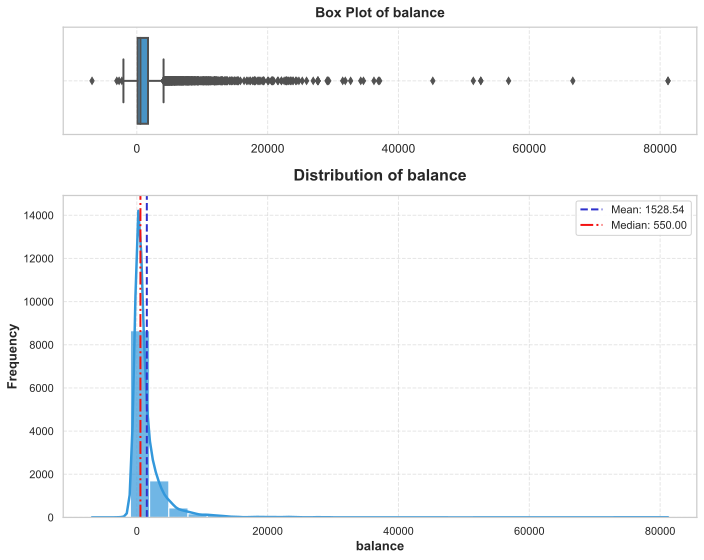

Статистика для 'balance':
  Mean:   1528.54
  Median: 550.00
  Std:    3225.41
  Min:    -6847.00
  Max:    81204.00
  Count:  11162
  Q1:     122.00
  Q3:     1708.00
  IQR:    1586.00


In [14]:
# вывод гистограммы
plot_hist_numeric(df, 'balance')

* Сильная правосторонняя асимметрия: среднее (1 528,54) заметно выше медианы (550,00) — это признак длинного «тяжёлого» правого хвоста;
* Высокая вариативность: стандартное отклонение (3 225,41) почти вдвое превышает среднее — данные сильно разбросаны;
* Широкий диапазон: от −6 847 до 81 204 (разброс более чем в 10 раз относительно среднего);
* Межквартильный размах (IQR = 1 586): основная масса наблюдений лежит между 1‑м (122) и 3‑м (1 708) квартилями, то есть в интервале 122–1 708.

*Необходимо сделать логарифмировнаие признака 'balance', создать новые признаки: размер долга, маркер должника. Ввод новых признаков для обучения модели LightGBM*.

*Анализ признака **duration***:
* график гистграммы скошен вправо, имеет смысл взять логарифм;
* нельзя использовать duration в финальной модели.

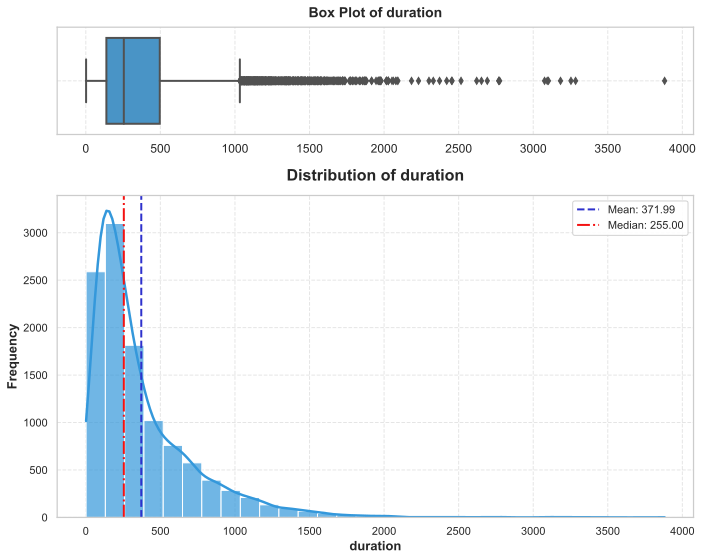

Статистика для 'duration':
  Mean:   371.99
  Median: 255.00
  Std:    347.13
  Min:    2.00
  Max:    3881.00
  Count:  11162
  Q1:     138.00
  Q3:     496.00
  IQR:    358.00


In [15]:
# вывод гистограммы
plot_hist_numeric(df, 'duration')

*Ярко выраженная сильная правосторонняя асимметрия (скошенность вправо). Не думаю, что стоит удалять "выбросы" - звонки. Надежней - сделать логарифмирование*

In [16]:
# логарифмирование признака 
'''
df['log_duration'] = np.log1p(df['duration'])
# вывод гистограммы
plot_hist_numeric(df, 'log_duration')

'''

"\ndf['log_duration'] = np.log1p(df['duration'])\n# вывод гистограммы\nplot_hist_numeric(df, 'log_duration')\n\n"

*Анализ признака **age***:
* в данном признаке фиксируем выбросы, которые необходимо удлаить;
* гистограмма скошена вправо, стоит провести логарифмирование.

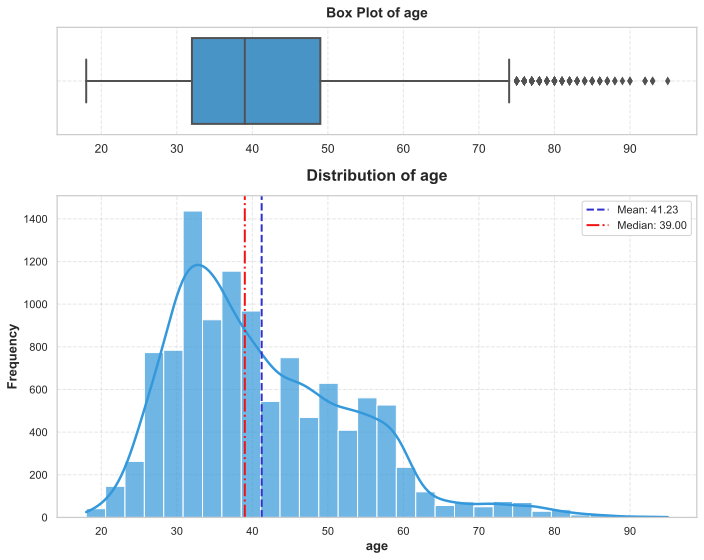

Статистика для 'age':
  Mean:   41.23
  Median: 39.00
  Std:    11.91
  Min:    18.00
  Max:    95.00
  Count:  11162
  Q1:     32.00
  Q3:     49.00
  IQR:    17.00


In [17]:
# вывод гистограммы
plot_hist_numeric(df, 'age')

*По гарвафику с усами можем сделать предположение, что люди старше 75 лет являются выбросами. Удалим клиентов старше 75 лет*

In [18]:
# удаляем выбросы
'''
df = df[df['age']<=75]
# логарифмирование признака 
df['log_age'] = np.log1p(df['age'])
# вывод гистограммы
plot_hist_numeric(df, 'log_age')

'''

"\ndf = df[df['age']<=75]\n# логарифмирование признака \ndf['log_age'] = np.log1p(df['age'])\n# вывод гистограммы\nplot_hist_numeric(df, 'log_age')\n\n"

*Анализ признака **campaign***:
* фиксируем выбросы: по формуле статистки, верхний/нижний "ус" =  медиана +- 1,5*IQR = (0.10, 3.10), считаю, что клиентов, которые выходят за данный интервал стоит удалить...

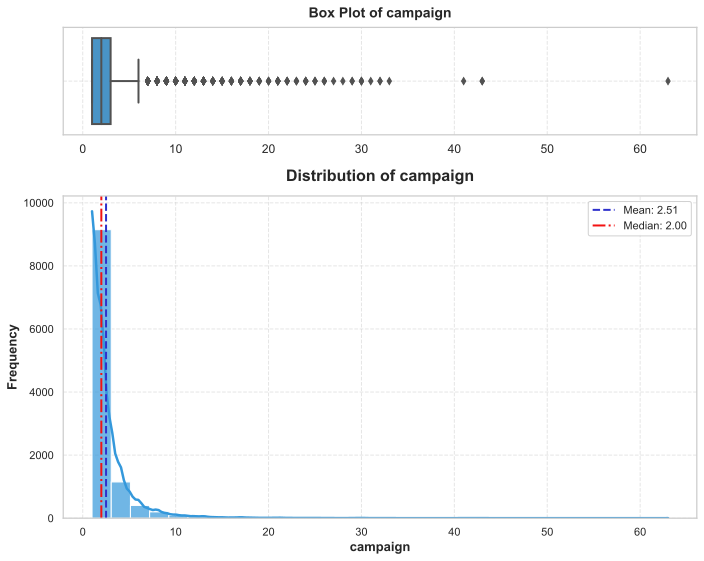

Статистика для 'campaign':
  Mean:   2.51
  Median: 2.00
  Std:    2.72
  Min:    1.00
  Max:    63.00
  Count:  11162
  Q1:     1.00
  Q3:     3.00
  IQR:    2.00


In [19]:
# вывод гистограммы
plot_hist_numeric(df, 'campaign')

In [20]:
# удалим клиентов, с которыми контактировали более 4 раз за кампанию 
'''
df = df[df['campaign']<=4]
# вывод гистограммы
plot_hist_numeric(df, 'campaign')

'''

"\ndf = df[df['campaign']<=4]\n# вывод гистограммы\nplot_hist_numeric(df, 'campaign')\n\n"

## 2.5 Анализ качесвтенных признаков

In [21]:
# вывод списка категориальных признаков 
print(categorical_features)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


### *Анализ признака **job***

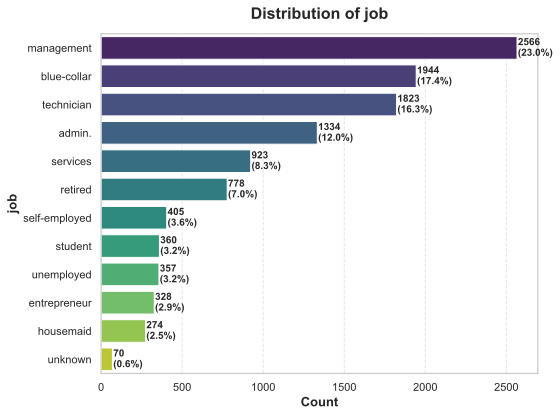

Статистика для 'job':
  Unique categories: 12
  Total count: 11162

Top categories:
  management: 2566 (23.0%)
  blue-collar: 1944 (17.4%)
  technician: 1823 (16.3%)
  admin.: 1334 (12.0%)
  services: 923 (8.3%)
  retired: 778 (7.0%)
  self-employed: 405 (3.6%)
  student: 360 (3.2%)
  unemployed: 357 (3.2%)
  entrepreneur: 328 (2.9%)


In [22]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'job')


* Доминирующая группа — management (23 %). Почти каждый четвёртый клиент в выборке — менеджер. Это может быть сильным сегментом для кампании: у них обычно выше доход/баланс и другая чувствительность к предложениям;
* «Тяжёлое» ядро из топ‑3: management + blue‑collar + technician = 57,2 % всей выборки. То есть больше половины клиентов попадают в эти три категории. Если модель будет плохо предсказывать конверсию именно для них — общая метрика сильно просядет;
* Средние категории (admin., services): ещё ~20 %. Это тоже значимые группы, их нельзя игнорировать;
* Малые категории (от retired и ниже): суммарно ~23 %, но каждая по отдельности уже небольшая (от 6 % и ниже). Для редких классов (вроде entrepreneur с 2,9 %) модель может просто не набрать достаточно примеров, чтобы выучить паттерн.


In [ ]:
# проведем объединение малых групп клиентов в подгруппу outher
'''
job_counts = df['job'].value_counts(normalize = True) # находим доли специальностей клиентов

list_smol_job = job_counts[job_counts <= 0.06].index.tolist() # список названий специальностей с маленькой долей

df.loc[df['job'].isin(list_smol_job), 'job'] = 'other' # замена

'''

"\njob_counts = df['job'].value_counts(normalize = True) # находим доли специальностей клиентов\n\nlist_smol_job = job_counts[job_counts <= 0.06].index.tolist() # список названий специальностей с маленькой долей\n\ndf.loc[df['job'].isin(list_smol_job), 'job'] = 'other' # замена\n\n"

### *Анализ признака **marital***

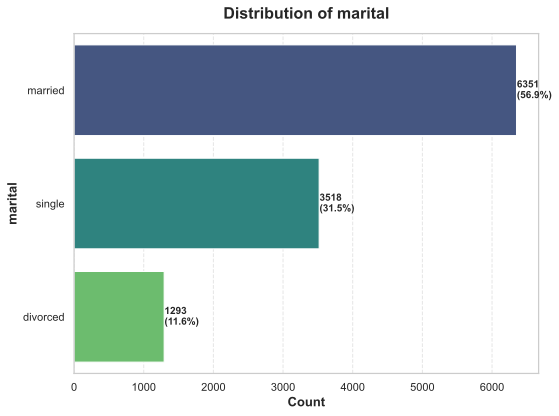

Статистика для 'marital':
  Unique categories: 3
  Total count: 11162

Top categories:
  married: 6351 (56.9%)
  single: 3518 (31.5%)
  divorced: 1293 (11.6%)


In [24]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'marital')

* Всего 3 категории, нет редких «хвостов», и распределение вполне сбалансированное (никакой категории с 1–2% нет);
* married (в браке) — 6 351 человек (56,9 %);
* single (не в браке / холост / незамужем) — 3 518 человек (31,5 %);
* divorced (в разводе) — 1 293 человека (11,6 %).

### *Анализ признака **education***

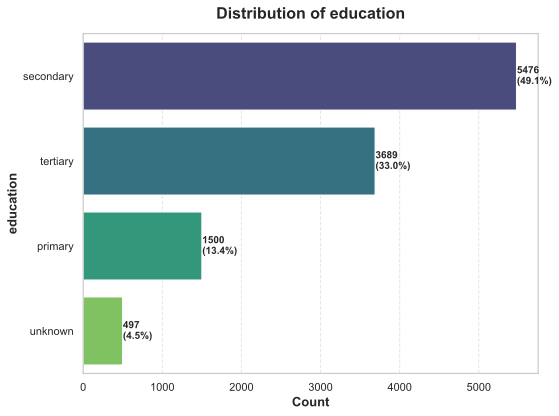

Статистика для 'education':
  Unique categories: 4
  Total count: 11162

Top categories:
  secondary: 5476 (49.1%)
  tertiary: 3689 (33.0%)
  primary: 1500 (13.4%)
  unknown: 497 (4.5%)


In [25]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'education')

 Тут 'unknown' надо объединить с 'primary', начальное образование вроде как все имеют...

In [26]:
# замена
'''
df['education'] = df['education'].replace('unknown', 'primary')
'''

"\ndf['education'] = df['education'].replace('unknown', 'primary')\n"

### *Анализ признака **default***

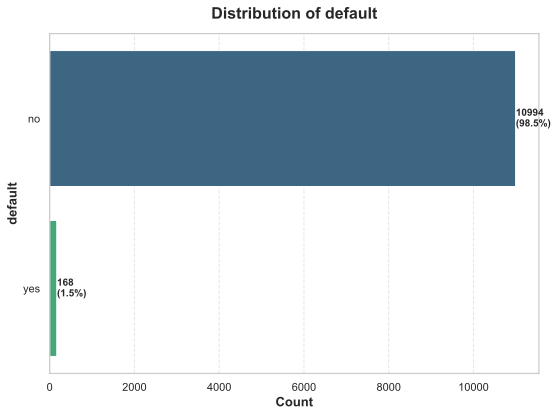

Статистика для 'default':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 10994 (98.5%)
  yes: 168 (1.5%)


In [27]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'default')

* Бинарный признак: только два значения — no и yes;
* Сильный дисбаланс классов: 98,5 % — no, 1,5 % — yes:
* Очень мало положительных случаев: всего 168 записей с yes — это критически мало для надёжной оценки влияния признака на целевую переменную;
* Риск недообучения на редком классе. Если целевая переменная тоже редкая (например, конверсия 10–15 %), модель может просто «игнорировать» группу yes, считая её шумом;
* Нельзя полагаться на accuracy. Точность вида «модель всегда предсказывает no и получает 98,5 % accuracy» будет обманчиво высокой. Нужны метрики, учитывающие дисбаланс: precision, recall, F1, ROC‑AUC, PR‑AUC;
* Высокий риск переобучения при кодировании. Из‑за малого числа yes любые сложные преобразования могут дать ложный эффект.

### *Анализ признака **housing***

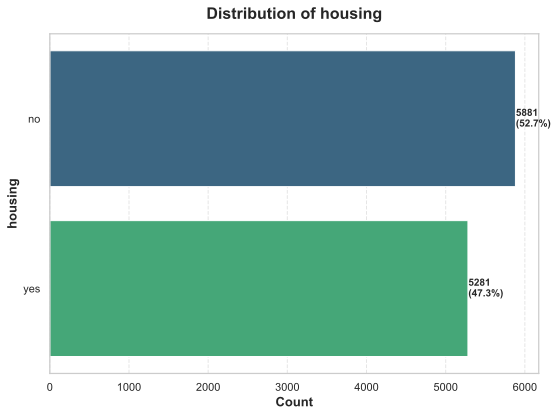

Статистика для 'housing':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 5881 (52.7%)
  yes: 5281 (47.3%)


In [28]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'housing')

* Бинарный признак: значения no и yes;
* Сбалансированное распределение: 52,7 % — no, 47,3 % — yes. Классы почти равны, сильного перекоса нет;
* Объём выборки: 11 162 наблюдения — статистически надёжная база для анализа.

### *Анализ признака **loan***

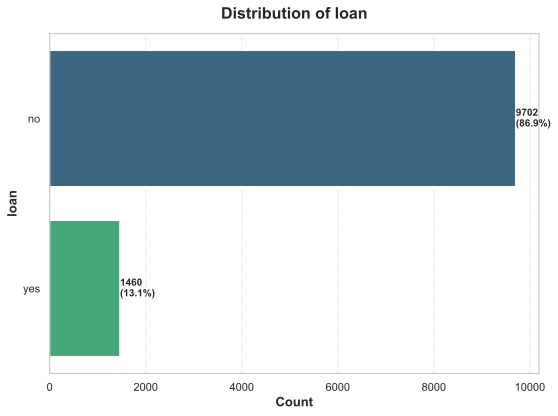

Статистика для 'loan':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 9702 (86.9%)
  yes: 1460 (13.1%)


In [29]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'loan')

* Бинарный признак: значения no и yes;
* Умеренный дисбаланс: 86,9 % — no, 13,1 % — yes. В отличие от default (где было всего 1,5 % редких случаев), здесь группа yes достаточно представительная (1 460 наблюдений) — её уже можно анализировать статистически;
* Объём выборки: 11 162 строки — надёжная база, чтобы не бояться, что редкие значения дадут шум.

### *Анализ признака **contact***

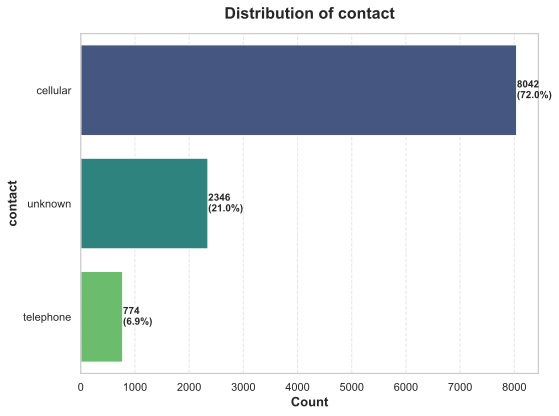

Статистика для 'contact':
  Unique categories: 3
  Total count: 11162

Top categories:
  cellular: 8042 (72.0%)
  unknown: 2346 (21.0%)
  telephone: 774 (6.9%)


In [30]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'contact')

* Категориальный признак с 3 уровнями: cellular, unknown, telephone;
* Умеренный дисбаланс: доминирует cellular (72 %), заметная доля unknown (21 %), и небольшая — telephone (6,9 %).

### *Анализ признака **month***

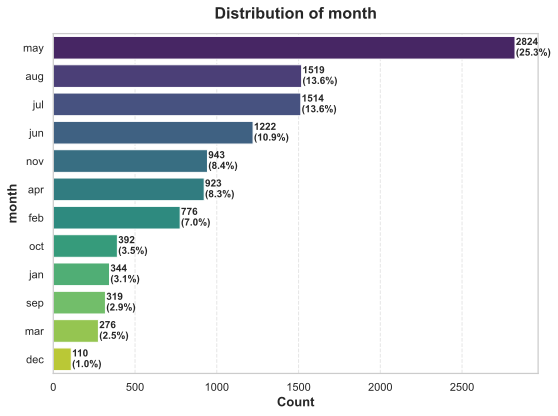

Статистика для 'month':
  Unique categories: 12
  Total count: 11162

Top categories:
  may: 2824 (25.3%)
  aug: 1519 (13.6%)
  jul: 1514 (13.6%)
  jun: 1222 (10.9%)
  nov: 943 (8.4%)
  apr: 923 (8.3%)
  feb: 776 (7.0%)
  oct: 392 (3.5%)
  jan: 344 (3.1%)
  sep: 319 (2.9%)


In [31]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'month')

* Категориальный признак, 12 значений (по месяцам);
* Ярко выраженная сезонность: почти четверть всех контактов — в мае (25,3 %), дальше идут август, июль, июнь (по 10–14 %);
* Сильный перекос: на топ‑4 месяца (may, aug, jul, jun) приходится ~63,4 % всех наблюдений. Остальные месяцы представлены слабо — особенно январь, сентябрь, октябрь (2,9–3,5 %).

### *Анализ признака **poutcome***

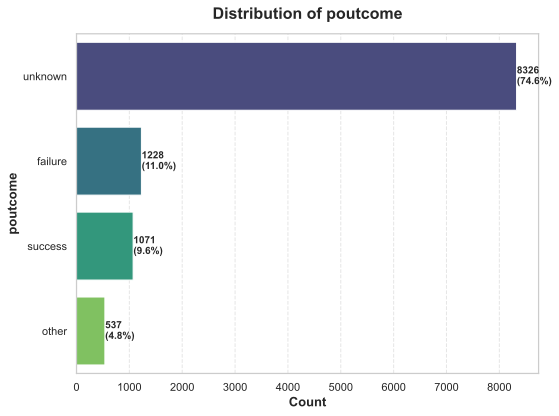

Статистика для 'poutcome':
  Unique categories: 4
  Total count: 11162

Top categories:
  unknown: 8326 (74.6%)
  failure: 1228 (11.0%)
  success: 1071 (9.6%)
  other: 537 (4.8%)


In [32]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'poutcome')

* Категориальный признак, 4 категории: unknown, failure, success, other;
* Сильный дисбаланс: 74,6 % — unknown, остальные категории суммарно 25,4 %;
* Редкие, но смысловые категории: success (9,6 %) и failure (11 %) — это как раз те клиенты, по которым есть конкретная история отклика; other (4,8 %) — скорее всего, смешанная группа (например, «не участвовал», «отказ по другой причине» и т.п.).

### *Анализ признака **deposit***

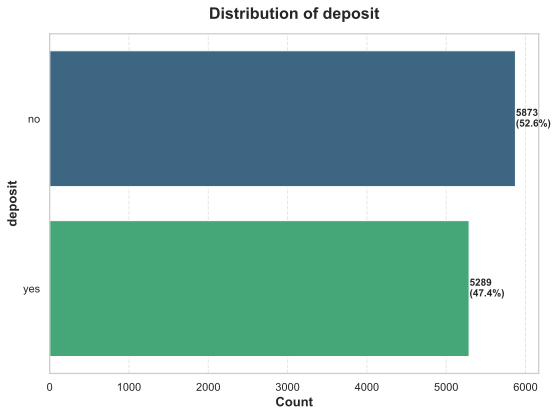

Статистика для 'deposit':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 5873 (52.6%)
  yes: 5289 (47.4%)


In [33]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'deposit')

* Бинарный признак: значения no и yes;
* Практически сбалансированное распределение: 52,6 % — no, 47,4 % — yes. Перекос минимальный (разница всего 5,2 п. п.), поэтому признак не требует балансировки.

# 3. Изучение взаимосвязей между признаками

## 3.1 Матрица корреляции

*Задача текущего блока - провести проверку на мультиколлинеарность между входными признаками, определить какие признаки больше всего коррелируют с целевым признаком...*

In [34]:
# посмотрим на корреляцию числовых признаков
corr_matrix = df.drop(categorical_features, axis=1).corr()

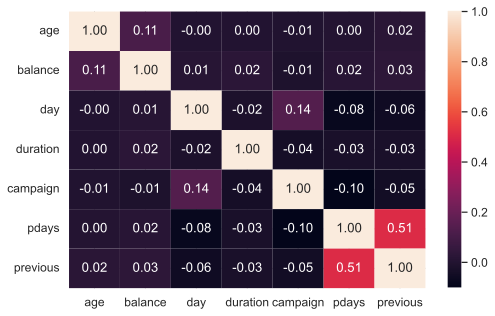

In [35]:
sns.heatmap(corr_matrix, annot = True, fmt = '.2f');

*Мультиколлинеарности между числовыми признаками не обнаружены...*

interval columns not set, guessing: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


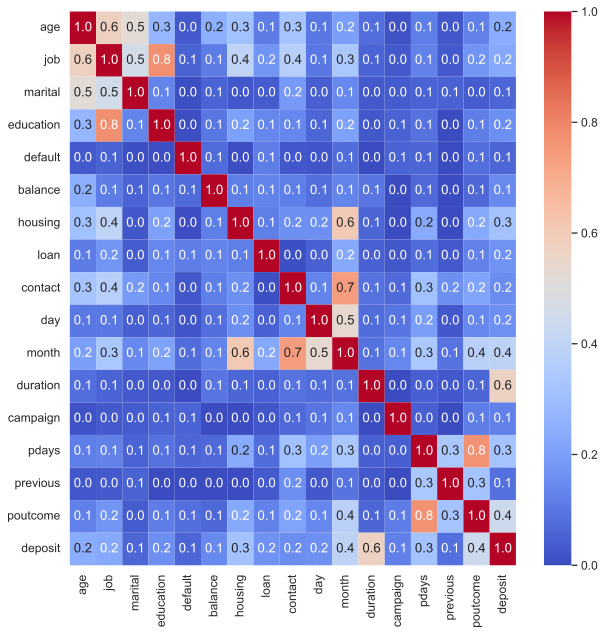

In [36]:
# поскольку в нашем датасете присутствуют категориальные признаки, используем корреляцию phik, которая способна с ними работать
plot_phik(df)

*Обнаружили сильную линейную зависимость между признаками:*
* job vs age;
* marital vs age;
* marital vs job;
* deposit vs duration;
* pdays vs poutcome;
* job vs education;
* contact vs month.

## 3.2 Изучение корреляций между выбранными парами

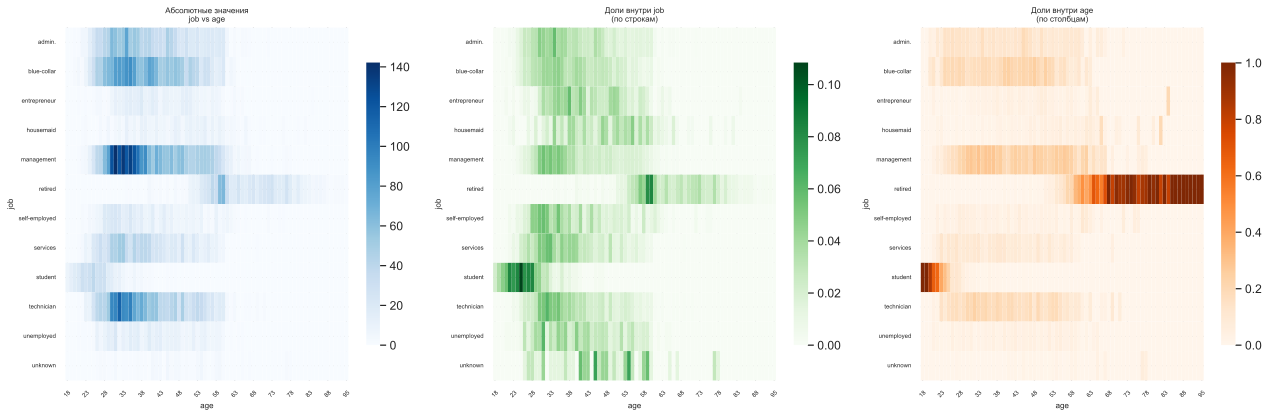

In [42]:
plot_categorical_relationship(df, 'job',  'age')

Установлено следующие:
* возраст на должности *студент* имеет интервал от 18 до 28;
* в датафрейме есть клиенты, которые вышщи на пенсию (от 53 до 95);
* возраст сотрудников по всем группа от 23 до 58 лет.

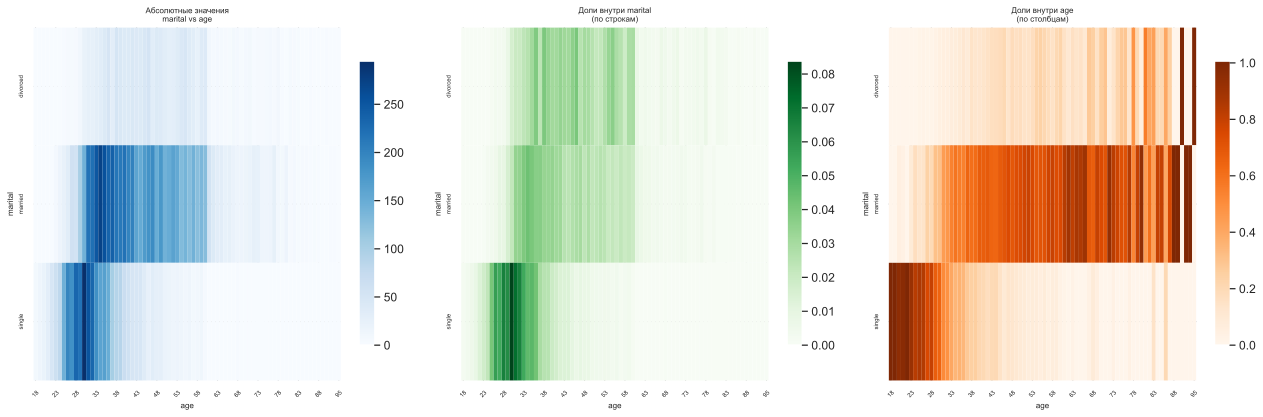

In [43]:
plot_categorical_relationship(df, 'marital', 'age')

Установлено следующие:
* большая часть клиентов в супружеских отношениях (возраст от 28 до 63 лет);
* возраст оиночек от 23 до 35;
* возраст у разведенных распределен равномерно.

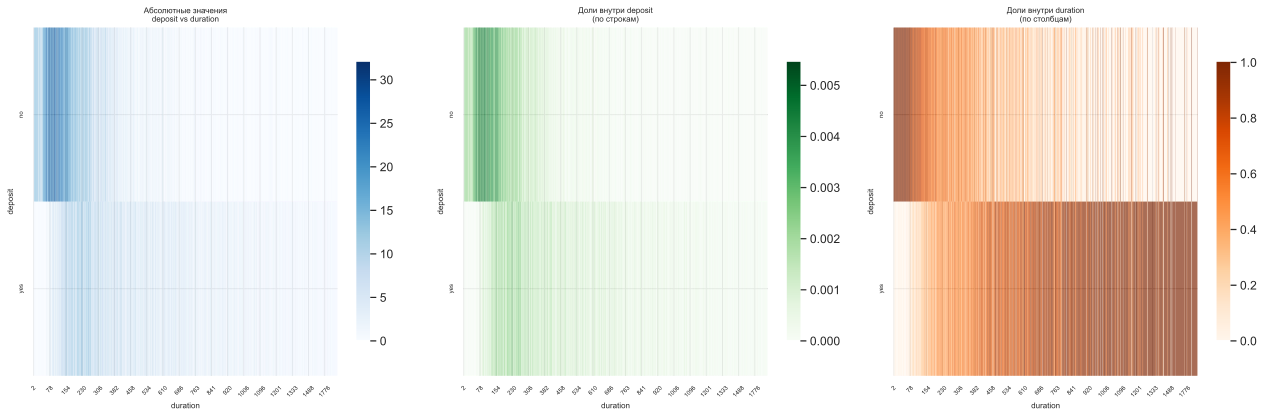

In [44]:
plot_categorical_relationship(df, 'deposit', 'duration')

Установлено следующие:
* большая часть клиентов, которые оформили депозит продолжали разговор от 154 секунд;
* клиенты, которые не оформили депозит, разговаривали до 154 секунд. 

# 4. Выводы и дальнейшие шаги

* *balance* имеет огромный разброс (от −6847 до 81 204) -> Необходимо сделать логарифмировнаие признака 'balance', создать новые признаки: размер долга, маркер должника. Ввод новых признаков для обучения модели LightGBM;
* Ярко выраженная сильная правосторонняя асимметрия признака *duration* (скошенность вправо). Не думаю, что стоит удалять "выбросы" - звонки. Надежней - сделать логарифмирование;
* По признаку *age* можем сделать предположение, что люди старше 75 лет являются выбросами. Удалим клиентов старше 75 лет c последующем логарифмированием;
* Удалим клиентов, с которыми контактировали более 4 раз за кампанию (признак *campaign*);

* Проведем объединение малых групп клиентов в подгруппу outher признака *job*;
* В признаке *ededucation* 'unknown' надо объединить с 'primary' (начальное образование вроде как все имеют);
* В признаке *default* жуткий дисбаланс классов, легче удалить данный признак, ибо он даже не коррелирует с целевым признаком;

